# Analisis Harga Bitcoin (BTC) Secara Real-Time
## Menggunakan PySpark MLlib

**Sumber data:** Yahoo Finance (yfinance) — Data historis BTC-USD 2021-2025

**Alur:** Ambil data dari Yahoo Finance → Simpan ke MongoDB → Preprocessing → Pipeline Spark MLlib (Linear Regression) → Prediksi harga → Evaluasi & Kesimpulan

## 0. Install Library yang Dibutuhkan

In [1]:
!pip install yfinance pymongo pyspark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 11.8 MB/s eta 0:00:00


## 1. Ambil Data BTC dari Yahoo Finance (Real-Time)

In [2]:
import yfinance as yf
import pandas as pd

# Download data BTC-USD dari Yahoo Finance tahun 2021-2025
btc = yf.download("BTC-USD", start="2021-01-01", end="2025-12-31", auto_adjust=True)

# Reset index supaya tanggal jadi kolom biasa
btc = btc.reset_index()
btc.columns = [col if isinstance(col, str) else col[0] for col in btc.columns]
btc["Date"] = btc["Date"].astype(str)

print(f"Jumlah data: {len(btc)} baris")
print(f"Periode: {btc['Date'].min()} s/d {btc['Date'].max()}")
btc.head()

[*********************100%***********************]  1 of 1 completed


Jumlah data: 1825 baris
Periode: 2021-01-01 s/d 2025-12-30


,Date,Close,High,Low,Open,Volume
0,2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359
1,2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765
2,2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202
3,2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344
4,2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782


## 2. Simpan Data ke MongoDB

In [3]:
print("Skip MongoDB di Colab")

Skip MongoDB di Colab


## 3. Membuat SparkSession & DataFrame

In [4]:
import sys, os
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lag, avg
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

spark = SparkSession.builder \
    .appName("AnalisisHargaBitcoin") \
    .master("local[1]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.ui.enabled", "false") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "1") \
    .config("spark.python.worker.reuse", "false") \
    .getOrCreate()

# Buat Spark DataFrame dari data BTC
df = spark.createDataFrame(btc[["Date", "Open", "High", "Low", "Close", "Volume"]])

print("SparkSession berhasil dibuat")
print(f"Jumlah baris: {df.count()}")
df.show(5)

SparkSession berhasil dibuat
Jumlah baris: 1825
+----------+---------------+---------------+---------------+---------------+-----------+
|      Date|           Open|           High|            Low|          Close|     Volume|
+----------+---------------+---------------+---------------+---------------+-----------+
|2021-01-01|28994.009765625|29600.626953125|  28803.5859375| 29374.15234375|40730301359|
|2021-01-02|29376.455078125|  33155.1171875|29091.181640625|32127.267578125|67865420765|
|2021-01-03|32129.408203125| 34608.55859375| 32052.31640625|  32782.0234375|78665235202|
|2021-01-04| 32810.94921875|    33440.21875|28722.755859375|  31971.9140625|81163475344|
|2021-01-05|31977.041015625| 34437.58984375|     30221.1875|  33992.4296875|67547324782|
+----------+---------------+---------------+---------------+---------------+-----------+
only showing top 5 rows


## 4. Preprocessing — Feature Engineering
Membuat fitur tambahan: harga kemarin (lag), rata-rata 7 hari, dan selisih harga.

In [5]:
from pyspark.sql.functions import col
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, avg as spark_avg

# Window berdasarkan urutan tanggal
w = Window.orderBy("Date")

df_feat = df \
    .withColumn("Close_lag1", lag("Close", 1).over(w)) \
    .withColumn("Close_lag2", lag("Close", 2).over(w)) \
    .withColumn("Close_lag3", lag("Close", 3).over(w)) \
    .withColumn("MA7", spark_avg("Close").over(w.rowsBetween(-6, 0))) \
    .withColumn("High_Low_diff", col("High") - col("Low")) \
    .dropna()

print("Setelah feature engineering:")
df_feat.select("Date", "Close", "Close_lag1", "MA7", "High_Low_diff").show(5)

Setelah feature engineering:
+----------+--------------+--------------+-----------------+--------------+
|      Date|         Close|    Close_lag1|              MA7| High_Low_diff|
+----------+--------------+--------------+-----------------+--------------+
|2021-01-04| 31971.9140625| 32782.0234375|31563.83935546875|4717.462890625|
|2021-01-05| 33992.4296875| 31971.9140625|  32049.557421875| 4216.40234375|
|2021-01-06|36824.36328125| 33992.4296875| 32845.3583984375|  3365.6640625|
|2021-01-07|39371.04296875|36824.36328125|33777.59905133928| 3689.17578125|
|2021-01-08|  40797.609375|39371.04296875|  35409.521484375|  5108.1015625|
+----------+--------------+--------------+-----------------+--------------+
only showing top 5 rows


## 5. Pipeline Spark MLlib (VectorAssembler → Linear Regression)

In [6]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

# Fitur yang dipakai untuk prediksi harga Close
feature_cols = ["Open", "High", "Low", "Volume", "Close_lag1", "Close_lag2", "Close_lag3", "MA7", "High_Low_diff"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
lr = LinearRegression(featuresCol="features", labelCol="Close", maxIter=10)

pipeline = Pipeline(stages=[assembler, lr])

print("Pipeline siap")

Pipeline siap


## 6. Training & Evaluasi Model

In [7]:
from pyspark.ml.evaluation import RegressionEvaluator

# Split data: 80% training, 20% testing
train_set, test_set = df_feat.randomSplit([0.8, 0.2], seed=42)

print(f"Data training: {train_set.count()} baris")
print(f"Data testing : {test_set.count()} baris")

# Training model
model = pipeline.fit(train_set)

# Prediksi pada data test
prediction = model.transform(test_set)

print("\n=== HASIL PREDIKSI vs HARGA ASLI ===")
prediction.select("Date", "Close", "prediction").show(10)

# Evaluasi
evaluator_rmse = RegressionEvaluator(labelCol="Close", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="Close", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(prediction)
r2 = evaluator_r2.evaluate(prediction)

print(f"\nRMSE (Root Mean Squared Error): {round(rmse, 2)}")
print(f"R² Score                       : {round(r2, 4)}")
print("(R² mendekati 1.0 = model semakin akurat)")

Data training: 1505 baris
Data testing : 317 baris

=== HASIL PREDIKSI vs HARGA ASLI ===
+----------+---------------+------------------+
|      Date|          Close|        prediction|
+----------+---------------+------------------+
|2021-01-06| 36824.36328125|35320.308660306815|
|2021-01-10| 38356.44140625| 39253.61388352435|
|2021-01-12|  33922.9609375| 34244.43441790836|
|2021-01-17| 35791.27734375|  35153.1617387535|
|2021-01-23|32067.642578125|32239.261621893384|
|2021-01-27|   30432.546875|31281.469011731602|
|2021-02-02|  35510.2890625| 34464.37383674305|
|2021-02-08| 46196.46484375| 42561.96266145455|
|2021-02-18|   51679.796875| 52179.08203203168|
|2021-02-19|  55888.1328125| 53987.12307788931|
+----------+---------------+------------------+
only showing top 10 rows

RMSE (Root Mean Squared Error): 908.46
R² Score                       : 0.9991
(R² mendekati 1.0 = model semakin akurat)


## 7. Visualisasi Harga Asli vs Prediksi

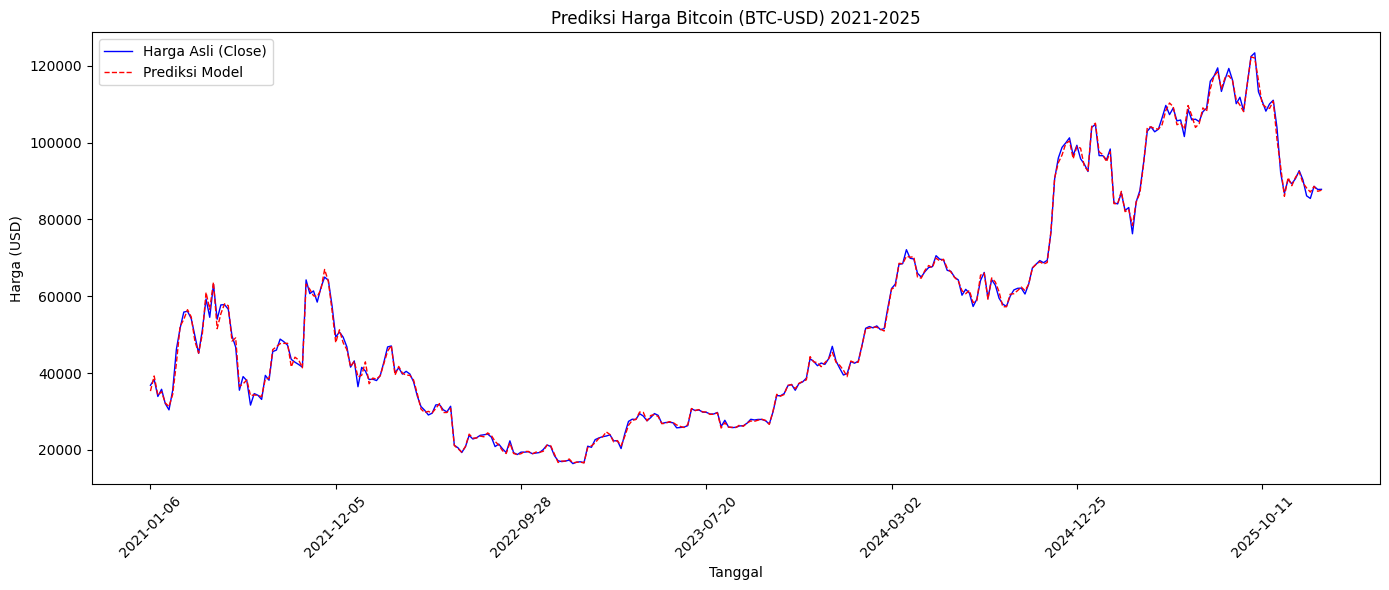

Grafik disimpan ke grafik_prediksi_btc.png


In [8]:
import matplotlib.pyplot as plt

# Konversi ke pandas untuk visualisasi
pred_pandas = prediction.select("Date", "Close", "prediction").toPandas()
pred_pandas = pred_pandas.sort_values("Date")

plt.figure(figsize=(14, 6))
plt.plot(pred_pandas["Date"], pred_pandas["Close"], label="Harga Asli (Close)", color="blue", linewidth=1)
plt.plot(pred_pandas["Date"], pred_pandas["prediction"], label="Prediksi Model", color="red", linestyle="--", linewidth=1)
plt.title("Prediksi Harga Bitcoin (BTC-USD) 2021-2025")
plt.xlabel("Tanggal")
plt.ylabel("Harga (USD)")
plt.xticks(pred_pandas["Date"][::50], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("grafik_prediksi_btc.png", dpi=100)
plt.show()
print("Grafik disimpan ke grafik_prediksi_btc.png")

## 8. Simpan Hasil Prediksi ke MongoDB & CSV

In [9]:
# Simpan ke CSV saja (MongoDB tidak tersedia di Colab)
pred_pandas.to_csv("hasil_prediksi_btc.csv", index=False)
print("Hasil disimpan ke CSV")
pred_pandas.head(10)

Hasil disimpan ke CSV


,Date,Close,prediction
0,2021-01-06,36824.363281,35320.308660
1,2021-01-10,38356.441406,39253.613884
2,2021-01-12,33922.960938,34244.434418
3,2021-01-17,35791.277344,35153.161739
4,2021-01-23,32067.642578,32239.261622
5,2021-01-27,30432.546875,31281.469012
6,2021-02-02,35510.289062,34464.373837
7,2021-02-08,46196.464844,42561.962661
8,2021-02-18,51679.796875,52179.082032
9,2021-02-19,55888.132812,53987.123078


Hasil evaluasi model menunjukkan RMSE sebesar 908.46 USD dan R² Score 0.9991,
yang berarti model mampu memprediksi harga Bitcoin dengan akurasi sangat tinggi
(99.91% variasi harga dapat dijelaskan oleh model).

In [10]:
spark.stop()

In [11]:
def label_sentimen(close, prev_close):
    if prev_close is None:
        return "netral"
    selisih = ((close - prev_close) / prev_close) * 100
    if selisih > 1:
        return "positif"
    elif selisih < -1:
        return "negatif"
    else:
        return "netral"

labels = []
for i in range(len(pred_pandas)):
    prev = pred_pandas.iloc[i-1]["Close"] if i > 0 else None
    labels.append(label_sentimen(pred_pandas.iloc[i]["Close"], prev))

pred_pandas["sentimen"] = labels
pred_pandas.to_csv("hasil_prediksi_btc_sentimen.csv", index=False)
print("Tersimpan!")
pred_pandas.head(10)

Tersimpan!


,Date,Close,prediction,sentimen
0,2021-01-06,36824.363281,35320.308660,netral
1,2021-01-10,38356.441406,39253.613884,positif
2,2021-01-12,33922.960938,34244.434418,negatif
3,2021-01-17,35791.277344,35153.161739,positif
4,2021-01-23,32067.642578,32239.261622,negatif
5,2021-01-27,30432.546875,31281.469012,negatif
6,2021-02-02,35510.289062,34464.373837,positif
7,2021-02-08,46196.464844,42561.962661,positif
8,2021-02-18,51679.796875,52179.082032,positif
9,2021-02-19,55888.132812,53987.123078,positif


In [12]:
import pandas as pd

# Ambil 80% pertama sebagai data training (sama seperti split di model)
n_train = int(len(btc) * 0.8)
train_pandas = btc.iloc[:n_train][["Date", "Open", "High", "Low", "Close", "Volume"]]
train_pandas.to_csv("data_training_btc.csv", index=False)
print(f"Tersimpan! Jumlah data: {len(train_pandas)}")
train_pandas.head()

Tersimpan! Jumlah data: 1460


,Date,Open,High,Low,Close,Volume
0,2021-01-01,28994.009766,29600.626953,28803.585938,29374.152344,40730301359
1,2021-01-02,29376.455078,33155.117188,29091.181641,32127.267578,67865420765
2,2021-01-03,32129.408203,34608.558594,32052.316406,32782.023438,78665235202
3,2021-01-04,32810.949219,33440.218750,28722.755859,31971.914062,81163475344
4,2021-01-05,31977.041016,34437.589844,30221.187500,33992.429688,67547324782
